In [94]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve

## Parámetros del sistema y configuración de simulación

In [95]:
# Tank cross-sectional areas [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Outlet orifice areas [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Pump flow constants [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Flow division parameters between upper and lower tanks
gamma1, gamma2 = 0.70, 0.60

# Constant gravitational acceleration [cm/s^2]
g = 981.0

# Time configuration and integration step
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Initial conditions for the levels of the four tanks [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Standard deviation of Gaussian noise for inputs and outputs
noise_input_std = 0.1
noise_output_std = 0.1

# Duration of steps for the excitation signal
t_change_min = 50
t_change_max = 50

# Voltage operating limits for the water pumps
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

El sistema se describe mediante el siguiente conjunto de ecuaciones acopladas:

$$\frac{dh_1}{dt} = -\frac{a_1}{A_1} \sqrt{2gh_1} + \frac{a_3}{A_1} \sqrt{2gh_3} + \frac{\gamma_1 k_1}{A_1} v_1$$
$$\frac{dh_2}{dt} = -\frac{a_2}{A_2} \sqrt{2gh_2} + \frac{a_4}{A_2} \sqrt{2gh_4} + \frac{\gamma_2 k_2}{A_2} v_2$$
$$\frac{dh_3}{dt} = -\frac{a_3}{A_3} \sqrt{2gh_3} + \frac{(1 - \gamma_2) k_2}{A_3} v_2$$
$$\frac{dh_4}{dt} = -\frac{a_4}{A_4} \sqrt{2gh_4} + \frac{(1 - \gamma_1) k_1}{A_4} v_1$$


In [96]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Unpack levels for the four tanks
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Numerical protection to avoid square roots of negative values
    h_safe = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_safe

    # Get input voltages at time t
    v1, v2 = u_func(t)

    # Mass balance for lower tanks with inflow from upper tanks
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Mass balance for upper tanks fed by divided flow
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Return state derivatives for the integrator
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [97]:
# Random number generator configuration with a fixed seed
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Initialization of indexes for signal level changes
t_change_indexes = []
curr_idx = 0

# Generation of random duration intervals for the steps
while curr_idx < n:
    t_change_indexes.append(curr_idx)

    # Calculation of step duration in seconds and its equivalent in steps
    duration_seg = rng_stream.uniform(t_change_min, t_change_max)
    step_sequences = int(duration_seg / dt)
    curr_idx += step_sequences

# Generation of random amplitudes for the voltages of both pumps
steps_values = rng_stream.uniform(V_min, V_max, size=(len(t_change_indexes), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [98]:
# Initialization of the matrix for the ideal input signal (no noise)
u_ideal = np.zeros((n, 2))

# Construction of the piecewise constant signal based on change indexes
for i in range(len(t_change_indexes)):
    idx_start = t_change_indexes[i]

    # Definition of the upper limit for the current interval
    if i == len(t_change_indexes) - 1:
        idx_end = n
    else:
        idx_end = t_change_indexes[i+1]

    # Assignment of voltages v1 and v2 for the defined time segment
    u_ideal[idx_start:idx_end, :] = steps_values[i]

# Generation of Gaussian white noise to simulate actuator uncertainty
noise_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Application of noise and clipping the signal to physical operating limits
u_noisy = u_ideal + noise_input
u_noisy = np.clip(u_noisy, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [99]:
# Creation of interpolation function for the noisy input
u_fun = interp1d(t, u_noisy, axis=0, kind='linear', fill_value='extrapolate')

# Definition of the wrapper to integrate the model with fixed parameters
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Solving the system of differential equations using RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extraction and organization of the simulated level trajectories
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [100]:
# Generation of Gaussian white noise for the sensors of the four tanks
noise_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
noise_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
noise_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
noise_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Application of noise to simulated levels with lower physical limit restriction
h1_noisy = np.maximum(h1_sim + noise_h1, 0.0)
h2_noisy = np.maximum(h2_sim + noise_h2, 0.0)
h3_noisy = np.maximum(h3_sim + noise_h3, 0.0)
h4_noisy = np.maximum(h4_sim + noise_h4, 0.0)

# Consolidation of time vectors, noisy inputs, and measured levels
t_full = t_out
u_full = u_noisy
h1_full = h1_noisy
h2_full = h2_noisy
h3_full = h3_noisy
h4_full = h4_noisy

# Definition of the total dimension for the training dataset
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

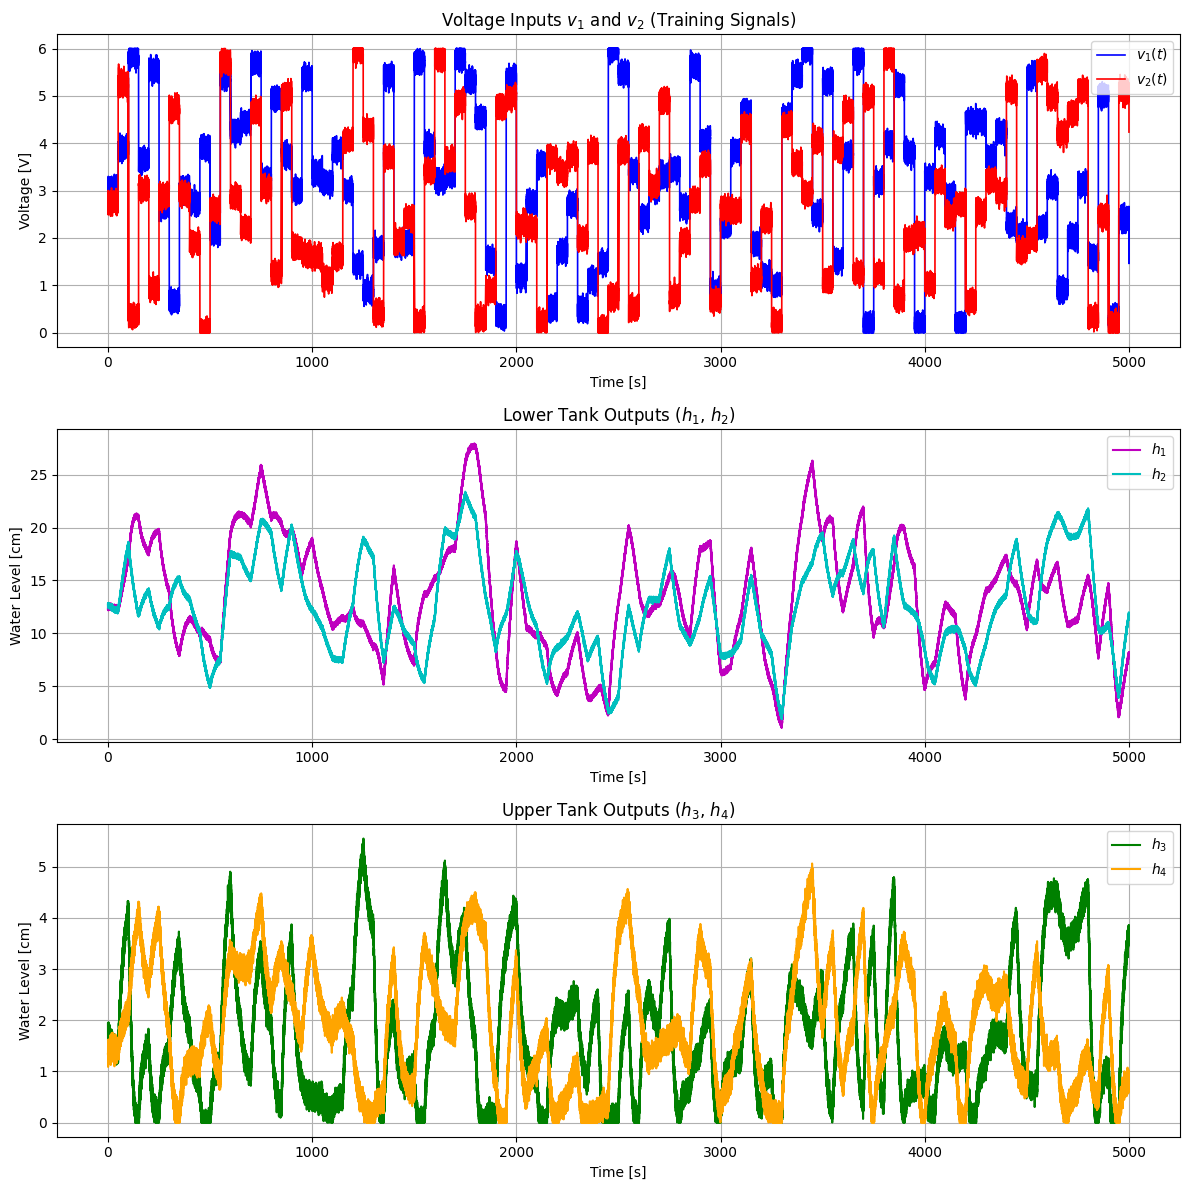

In [101]:
# Creation of the canvas for training signal visualization
plt.figure(figsize=(12, 12))

# Visualization of the input voltages applied to the pumps
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Voltage Inputs $v_1$ and $v_2$ (Training Signals)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the lower tanks
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Lower Tank Outputs ($h_1$, $h_2$)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the upper tanks
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Upper Tank Outputs ($h_3$, $h_4$)')
plt.legend(loc='upper right')
plt.grid(True)

# Layout adjustment and subplots display
plt.tight_layout()
plt.show()

In [102]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Level estimation
    P = np.zeros(n)          # Error covariance
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Prediction
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q

        # Update
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
        
    return x_hat

# Application with tuning parameters (Q: process, R: sensor)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

In [103]:
from scipy.optimize import fsolve

# Define operating voltage
v1_op = 1.50
v2_op = 4.50
u_op = np.array([v1_op, v2_op])

# Analytical calculation of the equilibrium point (h_op)
h3_op = ((1 - gamma2) * k2 * v2_op / a3)**2 / (2 * g)
h4_op = ((1 - gamma1) * k1 * v1_op / a4)**2 / (2 * g)
h1_op = (gamma1 * k1 * v1_op + a3 * np.sqrt(2 * g * h3_op))**2 / (a1**2 * 2 * g)
h2_op = (gamma2 * k2 * v2_op + a4 * np.sqrt(2 * g * h4_op))**2 / (a2**2 * 2 * g)

h_op = np.array([h1_op, h2_op, h3_op, h4_op])

print(f"Operating point Voltage: v1={v1_op:.2f}V, v2={v2_op:.2f}V")
print(f"Calculated equilibrium levels: h1={h_op[0]:.2f}, h2={h_op[1]:.2f}, h3={h_op[2]:.2f}, h4={h_op[3]:.2f} [cm]")

Operating point Voltage: v1=1.50V, v2=4.50V
Calculated equilibrium levels: h1=9.18, h2=17.44, h3=3.68, h4=0.35 [cm]


In [104]:
# Characteristic discharge times based on equilibrium points
T1 = (A1 / a1) * np.sqrt(2 * h_op[0] / g)
T2 = (A2 / a2) * np.sqrt(2 * h_op[1] / g)
T3 = (A3 / a3) * np.sqrt(2 * h_op[2] / g)
T4 = (A4 / a4) * np.sqrt(2 * h_op[3] / g)

print(f"T1: {T1:.2f}, T2: {T2:.2f}, T3: {T3:.2f}, T4: {T4:.2f}")

# State matrix A representing linearized system dynamics
A = np.array([
    [-1/T1,     0,      (A3/(A1*T3)),      0],
    [0,      -1/T2,          0,       (A4/(A2*T4))],
    [0,         0,        -1/T3,           0],
    [0,         0,           0,        -1/T4]
])

# Input matrix B representing the effect of pump voltages
B = np.array([
    [(gamma1 * k1 / A1),       0],
    [0,                 (gamma2 * k2 / A2)],
    [0,           ((1 - gamma2) * k2 / A3)],
    [((1 - gamma1) * k1 / A4),       0]
])

# Identity output matrix C assuming all levels are measured
C = np.eye(4)

# Zero direct transmission matrix D
D = np.zeros((4, 2))

print("Matriz A (Dinámica de estados):")
print(np.round(A, 4))
print("\nMatriz B (Efecto de las bombas):")
print(np.round(B, 4))

T1: 53.94, T2: 105.86, T3: 34.14, T4: 15.04
Matriz A (Dinámica de estados):
[[-0.0185  0.      0.0293  0.    ]
 [ 0.     -0.0094  0.      0.0665]
 [ 0.      0.     -0.0293  0.    ]
 [ 0.      0.      0.     -0.0665]]

Matriz B (Efecto de las bombas):
[[0.0832 0.    ]
 [0.     0.0628]
 [0.     0.0479]
 [0.0312 0.    ]]


In [105]:
# Linearized ODE system function using state deviations
def linear_ode_system(t, delta_h, u_func, A, B, u_op):
    # Current input acquisition and deviation calculation
    u_t = u_func(t)
    delta_u = u_t - u_op

    # Current absolute level calculation
    h_actual = delta_h + h_op

    # Linear state equation: d(delta_h)/dt = A * delta_h + B * delta_u
    ddelta_h_dt = A @ delta_h + B @ delta_u
            
    return ddelta_h_dt

# Initial conditions for the linear model as deviations from equilibrium
delta_h0 = h0 - h_op

# Integration of the linearized state-space model
sol_linear = solve_ivp(
    fun=lambda tt, hh: linear_ode_system(tt, hh, u_fun, A, B, u_op),
    t_span=[t[0], t[-1]],
    y0=delta_h0,
    method='RK45',
    t_eval=t
)

# Total level reconstruction by adding the equilibrium point to the deviations
h_linear_sim = sol_linear.y.T + h_op

In [106]:
# Helper function to compute RMSE and VAF between real and predicted signals
def calculate_metrics(real, pred):
    rmse = np.sqrt(np.mean((real - pred)**2))
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)
    return rmse, vaf

# Metrics calculation for each tank by comparing nonlinear simulation with linear model
rmse1, vaf1 = calculate_metrics(h1_full, h_linear_sim[:, 0])
rmse2, vaf2 = calculate_metrics(h2_full, h_linear_sim[:, 1])
rmse3, vaf3 = calculate_metrics(h3_full, h_linear_sim[:, 2])
rmse4, vaf4 = calculate_metrics(h4_full, h_linear_sim[:, 3])

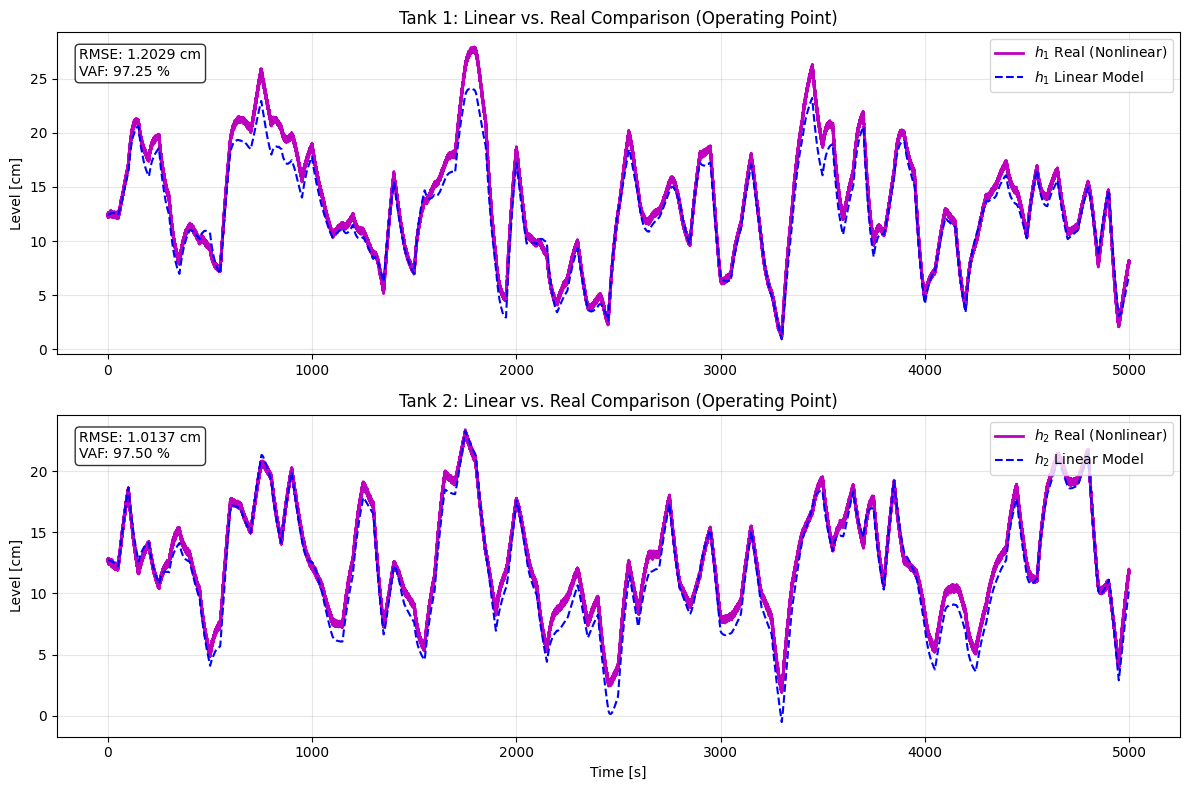

In [107]:
# --- PIECE NO. 1: LOWER TANKS ---
plt.figure(figsize=(12, 8))

# Tank 1: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h1_full, 'm', linewidth=2, label='$h_1$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 0], 'b--', linewidth=1.5, label='$h_1$ Linear Model')
plt.ylabel('Level [cm]')
plt.title('Tank 1: Linear vs. Real Comparison (Operating Point)')
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 2: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h2_full, 'm', linewidth=2, label='$h_2$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 1], 'b--', linewidth=1.5, label='$h_2$ Linear Model')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 2: Linear vs. Real Comparison (Operating Point)')
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
import pandas as pd

# 1. Crear un diccionario con los nombres exactos de las columnas y sus variables
datos_linealizacion = {
    'Tiempo [s]': t_full,
    'h1_Real [cm]': h1_full,
    'h2_Real [cm]': h2_full,
    'h1_Classical [cm]': h_linear_sim[:, 0],
    'h2_Classical [cm]': h_linear_sim[:, 1]
}

# 2. Convertir el diccionario en un DataFrame de Pandas
df_linealizacion = pd.DataFrame(datos_linealizacion)

# 3. Guardar el DataFrame en un archivo .csv sin incluir el índice de las filas
nombre_archivo_lin = 'comparacion_linealizacion_tanques_inferiores.csv'
df_linealizacion.to_csv(nombre_archivo_lin, index=False)

print(f"Resultados de linealización guardados exitosamente en '{nombre_archivo_lin}'")

Resultados de linealización guardados exitosamente en 'comparacion_linealizacion_tanques_inferiores.csv'


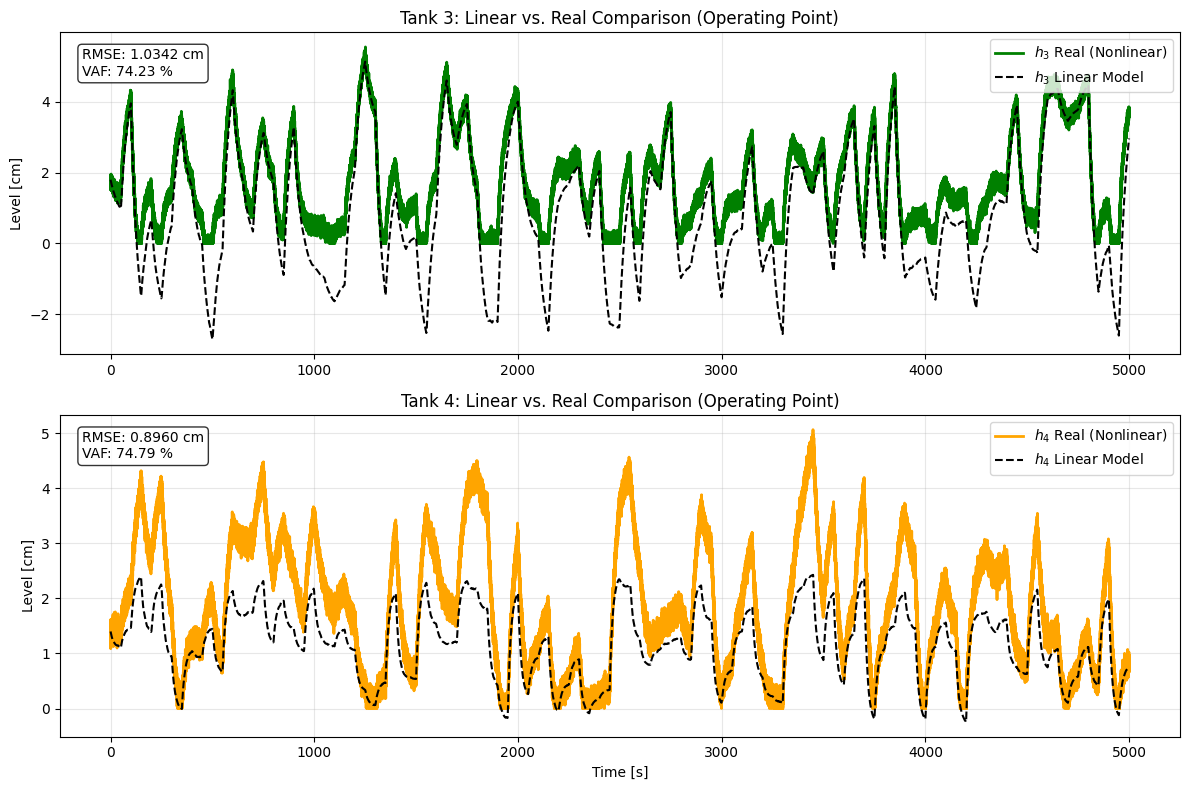

In [109]:
# --- PIECE NO. 2: UPPER TANKS ---
plt.figure(figsize=(12, 8))

# Tank 3: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h3_full, 'g', linewidth=2, label='$h_3$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 2], 'k--', linewidth=1.5, label='$h_3$ Linear Model')
plt.ylabel('Level [cm]')
plt.title('Tank 3: Linear vs. Real Comparison (Operating Point)')
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 4: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h4_full, 'orange', linewidth=2, label='$h_4$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 3], 'k--', linewidth=1.5, label='$h_4$ Linear Model')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 4: Linear vs. Real Comparison (Operating Point)')
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [110]:
import pandas as pd

# 1. Crear un diccionario con los nombres exactos de las columnas y sus variables correspondientes
datos_linealizacion_sup = {
    'Tiempo [s]': t_full,
    'h3_Real [cm]': h3_full,
    'h4_Real [cm]': h4_full,
    'h3_Classical [cm]': h_linear_sim[:, 2],
    'h4_Classical [cm]': h_linear_sim[:, 3]
}

# 2. Convertir el diccionario en un DataFrame de Pandas
df_linealizacion_sup = pd.DataFrame(datos_linealizacion_sup)

# 3. Guardar el DataFrame en un archivo .csv sin incluir el índice de las filas
nombre_archivo_lin_sup = 'comparacion_linealizacion_tanques_superiores.csv'
df_linealizacion_sup.to_csv(nombre_archivo_lin_sup, index=False)

print(f"Resultados de linealización de tanques superiores guardados exitosamente en '{nombre_archivo_lin_sup}'")

Resultados de linealización de tanques superiores guardados exitosamente en 'comparacion_linealizacion_tanques_superiores.csv'


In [111]:
from scipy.optimize import minimize

# =====================================================================
# PASO 2 MODIFICADO: OPTIMIZACIÓN NUMÉRICA PARA PID DESCENTRALIZADO
# =====================================================================

# Funciones de referencia temporales exclusivas para la optimización 
# (Queremos que el optimizador vea cómo se comportan ante escalones)
ref_opt1 = lambda t: np.where(t >= 50, h_op[0] + 2.0, h_op[0])
ref_opt2 = lambda t: np.where(t >= 250, h_op[1] - 2.0, h_op[1])

def cl_ode_for_optimization(t, states, Kp1, Ki1, Kd1, Kp2, Ki2, Kd2):
    h1, h2, h3, h4, xi1, xi2 = states
    r1, r2 = ref_opt1(t), ref_opt2(t)
    
    e1, e2 = r1 - h1, r2 - h2
    
    # Para la acción derivativa continua, necesitamos las derivadas del proceso en el instante anterior.
    # Como aproximación estricta y limpia, calculamos las derivadas de los niveles (dh/dt) sin el término Kd primero:
    eps = 1e-6
    h_safe = np.maximum([h1, h2, h3, h4], eps)
    
    # Dinámica base de la planta (aproximada para evaluar el cambio de error)
    v1_base = np.clip(u_op[0] + Kp1 * e1 + Ki1 * xi1, V_min, V_max)
    v2_base = np.clip(u_op[1] + Kp2 * e2 + Ki2 * xi2, V_min, V_max)
    
    dh1dt_base = -(a1 / A1) * np.sqrt(2 * g * h_safe[0]) + (a3 / A1) * np.sqrt(2 * g * h_safe[2]) + (gamma1 * k1 / A1) * v1_base
    dh2dt_base = -(a2 / A2) * np.sqrt(2 * g * h_safe[1]) + (a4 / A2) * np.sqrt(2 * g * h_safe[3]) + (gamma2 * k2 / A2) * v2_base
    
    # de/dt = -dh/dt (asumiendo referencia constante en la vecindad del punto)
    dedt1 = -dh1dt_base
    dedt2 = -dh2dt_base
    
    # Ley de control PID Completa
    v1 = np.clip(u_op[0] + Kp1 * e1 + Ki1 * xi1 + Kd1 * dedt1, V_min, V_max)
    v2 = np.clip(u_op[1] + Kp2 * e2 + Ki2 * xi2 + Kd2 * dedt2, V_min, V_max)
    
    # Re-evaluación real con los voltajes PID correctos
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h_safe[0]) + (a3 / A1) * np.sqrt(2 * g * h_safe[2]) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h_safe[1]) + (a4 / A2) * np.sqrt(2 * g * h_safe[3]) + (gamma2 * k2 / A2) * v2
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h_safe[2]) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h_safe[3]) + ((1 - gamma1) * k1 / A4) * v1
    
    return [dh1dt, dh2dt, dh3dt, dh4dt, e1, e2]

def objective_function(params):
    # Desempaquetar los parámetros que el optimizador está probando
    Kp1_t, Ki1_t, Kd1_t, Kp2_t, Ki2_t, Kd2_t = params
    
    # Tiempo corto de evaluación para la optimización (para que sea rápido)
    t_eval_opt = np.arange(0, 600, 2.0)
    init_states = np.append(h_op, [0.0, 0.0])
    
    sol = solve_ivp(
        fun=lambda tt, yy: cl_ode_for_optimization(tt, yy, Kp1_t, Ki1_t, Kd1_t, Kp2_t, Ki2_t, Kd2_t),
        t_span=[0, 600], y0=init_states, t_eval=t_eval_opt, method='RK45'
    )
    
    if not sol.success:
        return 1e10 # Penalización si el sistema se vuelve inestable
        
    # Calcular el índice numérico ITAE: Integral( t * |e(t)| * dt )
    e1_abs = np.abs(ref_opt1(sol.t) - sol.y[0])
    e2_abs = np.abs(ref_opt2(sol.t) - sol.y[1])
    
    itae = np.trapz(sol.t * (e1_abs + e2_abs), sol.t)
    return itae

# --- EJECUCIÓN DEL OPTIMIZADOR ---
print("Buscando los mejores parámetros Kp, Ki y Kd simultáneamente...")

# Punto de partida (Usamos los PI anteriores como base y Kd en 0.5 inicial)
initial_guess = [0.1411, 0.0025, 0.5, 0.1053, 0.0010, 0.5]

# Límites físicos para evitar ganancias negativas o absurdamente altas
bounds = [
    (0.01, 2.0), (1e-4, 0.05), (0.0, 10.0), # Límites PID 1
    (0.01, 2.0), (1e-4, 0.05), (0.0, 10.0)  # Límites PID 2
]

result = minimize(objective_function, x0=initial_guess, bounds=bounds, method='L-BFGS-B')

# Guardar las ganancias óptimas encontradas
Kp1, Ki1, Kd1, Kp2, Ki2, Kd2 = result.x

print("="*60)
print("PASO 2 MODIFICADO: PARÁMETROS PID ÓPTIMOS ENCONTRADOS")
print("="*60)
print(f"PID 1 Óptimo (h1): Kp = {Kp1:.4f}, Ki = {Ki1:.4f}, Kd = {Kd1:.4f}")
print(f"PID 2 Óptimo (h2): Kp = {Kp2:.4f}, Ki = {Ki2:.4f}, Kd = {Kd2:.4f}")
print(f"Éxito de la optimización: {result.success}")
print("="*60)

Buscando los mejores parámetros Kp, Ki y Kd simultáneamente...
PASO 2 MODIFICADO: PARÁMETROS PID ÓPTIMOS ENCONTRADOS
PID 1 Óptimo (h1): Kp = 2.0000, Ki = 0.0493, Kd = 0.0000
PID 2 Óptimo (h2): Kp = 2.0000, Ki = 0.0500, Kd = 9.9998
Éxito de la optimización: True


In [112]:
# Constant level reference generator
def constant_ref(t, value=12.0):
    return value

# Sinusoidal profile reference generator
def sinusoidal_ref(t, offset=12.0, amp=3.0, freq=0.0025):
    return offset + amp * np.sin(2 * np.pi * freq * t)

# Square wave type reference generator
def square_ref(t, offset=9.0, amp=2.0, freq=0.005):
    return offset + amp * np.sign(np.sin(2 * np.pi * freq * t))

# Charging/discharging dynamics reference generator (RC Filter)
def rc_filter_ref(t, tau=10.0, change_t=50.0, v1=10.0, v2=14.0):
    cycle = int(t / change_t)
    target = v2 if cycle % 2 != 0 else v1
    relative_t = t % change_t
    initial_v = v2 if target == v1 else v1
    return target + (initial_v - target) * np.exp(-relative_t / tau)

# Step sequence reference generator
def step_sequence_ref(t, values, period=200):
    index = int(t / period) % len(values)
    return values[index]

# Multivariable sinusoidal reference generator (MIMO)
def mimo_sinusoidal_ref(t, offset, amp_vector, period=400):
    freq = 1.0 / period
    return offset + amp_vector * np.sin(2 * np.pi * freq * t)

# Desired trajectory assignment for the controlled tanks
h1_reference = lambda t: step_sequence_ref(t, [12, 15, 10, 14, 16])
h2_reference = lambda t: step_sequence_ref(t, [16, 14, 10, 15, 12])
#h1_reference = lambda t: sinusoidal_ref(t)
#h2_reference = lambda t: sinusoidal_ref(t)

In [113]:
# =====================================================================
# EJECUCIÓN CON LAS NUEVAS REFERENCIAS LAMBDA
# =====================================================================

# Condiciones iniciales
initial_states_cl = np.append(h_op, [0.0, 0.0])

T_sim_pid = 1500.0  # Tiempo total de simulación del PID en segundos
dt_pid = 0.2       # Paso de tiempo para el guardado de datos del PID

t_pid = np.arange(0, T_sim_pid + dt_pid, dt_pid)
n_pid = len(t_pid)

# 1. Configuración de las desviaciones estándar solicitadas
noise_actuator_std = 0.15  # Desviación estándar para las bombas (v1, v2)
noise_sensor_std = 0.10    # Desviación estándar para los sensores (h1, h2)

seed_stream_pid = 1

# Usamos el generador de números aleatorios con la semilla de tu script
rng_pid = np.random.Generator(np.random.MT19937(seed_stream_pid))

# 2. Generación previa de los vectores de ruido basados en el tiempo discreto del PID
noise_v1 = noise_actuator_std * rng_pid.standard_normal(size=n_pid)
noise_v2 = noise_actuator_std * rng_pid.standard_normal(size=n_pid)

noise_s1 = noise_sensor_std * rng_pid.standard_normal(size=n_pid)
noise_s2 = noise_sensor_std * rng_pid.standard_normal(size=n_pid)

# Interpolamos los ruidos del actuador para que la ODE los consuma continuamente en cualquier instante 't'
noise_v1_func = interp1d(t_pid, noise_v1, kind='linear', fill_value='extrapolate')
noise_v2_func = interp1d(t_pid, noise_v2, kind='linear', fill_value='extrapolate')

# Primero, fuera de la ODE (justo abajo de donde creaste noise_s1 y noise_s2), interpolamos:
noise_s1_func = interp1d(t_pid, noise_s1, kind='linear', fill_value='extrapolate')
noise_s2_func = interp1d(t_pid, noise_s2, kind='linear', fill_value='extrapolate')

In [114]:
# =====================================================================
# MODIFICACIÓN FINAL: ODE CON RUIDO Y LIMITACIÓN DE SLEW RATE (+-0.5 V/s)
# =====================================================================

def cl_system_slew_rate_ode(t, states, Kp1, Ki1, Kd1, Kp2, Ki2, Kd2, h_op, u_op, V_min, V_max, h1_ref_func, h2_ref_func, noise_v1_func, noise_v2_func, noise_s1_func, noise_s2_func):
    # Desempaquetar los 8 estados actuales: 
    # Planta (h1..h4), Integradores PID (xi1, xi2) y Actuadores Dinámicos (v_act1, v_act2)
    h1, h2, h3, h4, xi1, xi2, v_act1, v_act2 = states
    
    r1 = h1_ref_func(t)
    r2 = h2_ref_func(t)
    
    # 1. El PID lee la medición con ruido de sensor interpolado
    h1_measured = h1 + noise_s1_func(t)
    h2_measured = h2 + noise_s2_func(t)
    
    e1 = r1 - h1_measured
    e2 = r2 - h2_measured
    
    # 2. Estimación analítica de de/dt = -dh/dt para la acción derivativa
    eps = 1e-6
    h_safe = np.maximum([h1, h2, h3, h4], eps)
    
    dh1dt_base = -(a1 / A1) * np.sqrt(2 * g * h_safe[0]) + (a3 / A1) * np.sqrt(2 * g * h_safe[2]) + (gamma1 * k1 / A1) * v_act1
    dh2dt_base = -(a2 / A2) * np.sqrt(2 * g * h_safe[1]) + (a4 / A2) * np.sqrt(2 * g * h_safe[3]) + (gamma2 * k2 / A2) * v_act2
    
    dedt1 = -dh1dt_base
    dedt2 = -dh2dt_base
    
    # 3. Ley de control teórica calculada por el PID
    v1_calc = u_op[0] + Kp1 * e1 + Ki1 * xi1 + Kd1 * dedt1
    v2_calc = u_op[1] + Kp2 * e2 + Ki2 * xi2 + Kd2 * dedt2
    
    # 4. Inyección de ruido en el actuador sobre la señal deseada
    v1_desired = np.clip(v1_calc + noise_v1_func(t), V_min, V_max)
    v2_desired = np.clip(v2_calc + noise_v2_func(t), V_min, V_max)
    
    # 5. DINÁMICA DEL LIMITADOR DE RAMPAS (Slew Rate Limit = 0.5 V/s)
    # Modelamos el actuador como un sistema rápido (tau_act = 0.01) que satura su velocidad de cambio
    tau_act = 0.01 
    slew_limit = 0.5  # Máxima variación permitida: 0.5 V por segundo
    
    dv1_dt = (v1_desired - v_act1) / tau_act
    dv2_dt = (v2_desired - v_act2) / tau_act
    
    # Aplicamos la saturación estricta de la derivada (+- 0.5 V/s)
    dv1_dt_sat = np.clip(dv1_dt, -slew_limit, slew_limit)
    dv2_dt_sat = np.clip(dv2_dt, -slew_limit, slew_limit)
    
    # 6. Dinámica real de la planta utilizando los voltajes reales de salida del actuador (v_act)
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h_safe[0]) + (a3 / A1) * np.sqrt(2 * g * h_safe[2]) + (gamma1 * k1 / A1) * v_act1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h_safe[1]) + (a4 / A2) * np.sqrt(2 * g * h_safe[3]) + (gamma2 * k2 / A2) * v_act2
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h_safe[2]) + ((1 - gamma2) * k2 / A3) * v_act2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h_safe[3]) + ((1 - gamma1) * k1 / A4) * v_act1
    
    # Devolver las 8 derivadas correspondientes
    return [dh1dt, dh2dt, dh3dt, dh4dt, e1, e2, dv1_dt_sat, dv2_dt_sat]

In [115]:
# =====================================================================
# 4. LANZAMIENTO Y EXTRACCIÓN CON ENTORNO DE SLEW RATE COMPLETO
# =====================================================================

# Configurar condiciones iniciales para 8 estados: [h1_op..h4_op, xi1_op, xi2_op, v1_op, v2_op]
# Esto evita transitorios artificiales en t=0 ya que las bombas arrancan en su punto de operación
import time

initial_states_cl = np.concatenate([h_op, [0.0, 0.0], u_op])

print("Simulando PID Descentralizado Óptimo con Ruido y Slew Rate Limit...")

# 1. Registrar el tiempo de CPU justo antes de iniciar la simulación
tic = time.perf_counter()

sol_cl = solve_ivp(
    fun=lambda tt, yy: cl_system_slew_rate_ode(
        tt, yy, Kp1, Ki1, Kd1, Kp2, Ki2, Kd2, h_op, u_op, V_min, V_max, 
        h1_reference, h2_reference, noise_v1_func, noise_v2_func, noise_s1_func, noise_s2_func
    ),
    t_span=[t_pid[0], t_pid[-1]], 
    y0=initial_states_cl, 
    method='RK45', 
    t_eval=t_pid, 
    rtol=1e-6, 
    atol=1e-8
)

toc = time.perf_counter()

# Extraer estados de los tanques
h1_cl, h2_cl = sol_cl.y[0], sol_cl.y[1]
xi1_cl, xi2_cl = sol_cl.y[4], sol_cl.y[5]
h1_real, h2_real = sol_cl.y[0], sol_cl.y[1]

# Señales de sensores con el ruido interpolado real aplicado en la simulación
h1_measured_v = h1_real + noise_s1
h2_measured_v = h2_real + noise_s2

# EXTRAER DIRECTAMENTE LOS VOLTAJES REALES (Estados 6 y 7 de la ODE)
# Ya vienen calculados, ruidosos, saturados en amplitud y limitados a +-0.5 V/s
v1_cl = sol_cl.y[6]
v2_cl = sol_cl.y[7]

# Vectorizar la evaluación de referencias para las gráficas (Adiós ciclo for)
r1_vec = np.array([h1_reference(ti) for ti in t_pid])
r2_vec = np.array([h2_reference(ti) for ti in t_pid])

Simulando PID Descentralizado Óptimo con Ruido y Slew Rate Limit...


In [116]:
# 1. Cálculos base de rendimiento temporal
cpu_time_seconds = toc - tic                  # Tiempo total que le tomó a la CPU
simulated_time_seconds = t_pid[-1] - t_pid[0]  # 1500.0 segundos físicos
rtf_pid = simulated_time_seconds / cpu_time_seconds

# Tiempo promedio que le tomó al solver por cada paso de guardado de datos
num_iterations = len(t_pid)
avg_time_per_iteration_ms = (cpu_time_seconds / num_iterations) * 1000

print("="*60)
print(f"Tiempo de CPU empleado: {cpu_time_seconds:.4f} segundos")
print(f"Tiempo físico simulado: {simulated_time_seconds:.1f} segundos")
print(f"REAL TIME FACTOR (RTF): {rtf_pid:.6f}")
print("="*60)

Tiempo de CPU empleado: 161.4562 segundos
Tiempo físico simulado: 1500.0 segundos
REAL TIME FACTOR (RTF): 9.290448


In [117]:
# 2. Organizamos las métricas de rendimiento en un diccionario
metrics_data_pid = {
    'Metric': [
        'Total Execution Time (s)', 
        'Average Time per Iteration (ms)', 
        'Total Physical Simulated Time (s)', 
        'Real-Time Factor (RTF)',
        'Status'
    ],
    'Value': [
        round(cpu_time_seconds, 4),
        round(avg_time_per_iteration_ms, 2),
        round(simulated_time_seconds, 2),
        round(rtf_pid, 4), # Guardamos 4 decimales para apreciar la velocidad del PID
        "Faster than Real-Time" if rtf_pid < 1.0 else "Slower than Real-Time"
    ]
}

# 3. Creamos el DataFrame de Pandas
df_performance_pid = pd.DataFrame(metrics_data_pid)

# 4. Guardamos en el archivo .csv correspondiente al benchmark lineal
nombre_archivo_rendimiento = 'performance_metrics_linear_taylor_pid_sinusoidal_10.csv'
#df_performance_pid.to_csv(nombre_archivo_rendimiento, index=False)

print("\n" + "="*60)
print(f"Métricas de rendimiento guardadas en '{nombre_archivo_rendimiento}'")
print("="*60)


Métricas de rendimiento guardadas en 'performance_metrics_linear_taylor_pid_sinusoidal_10.csv'


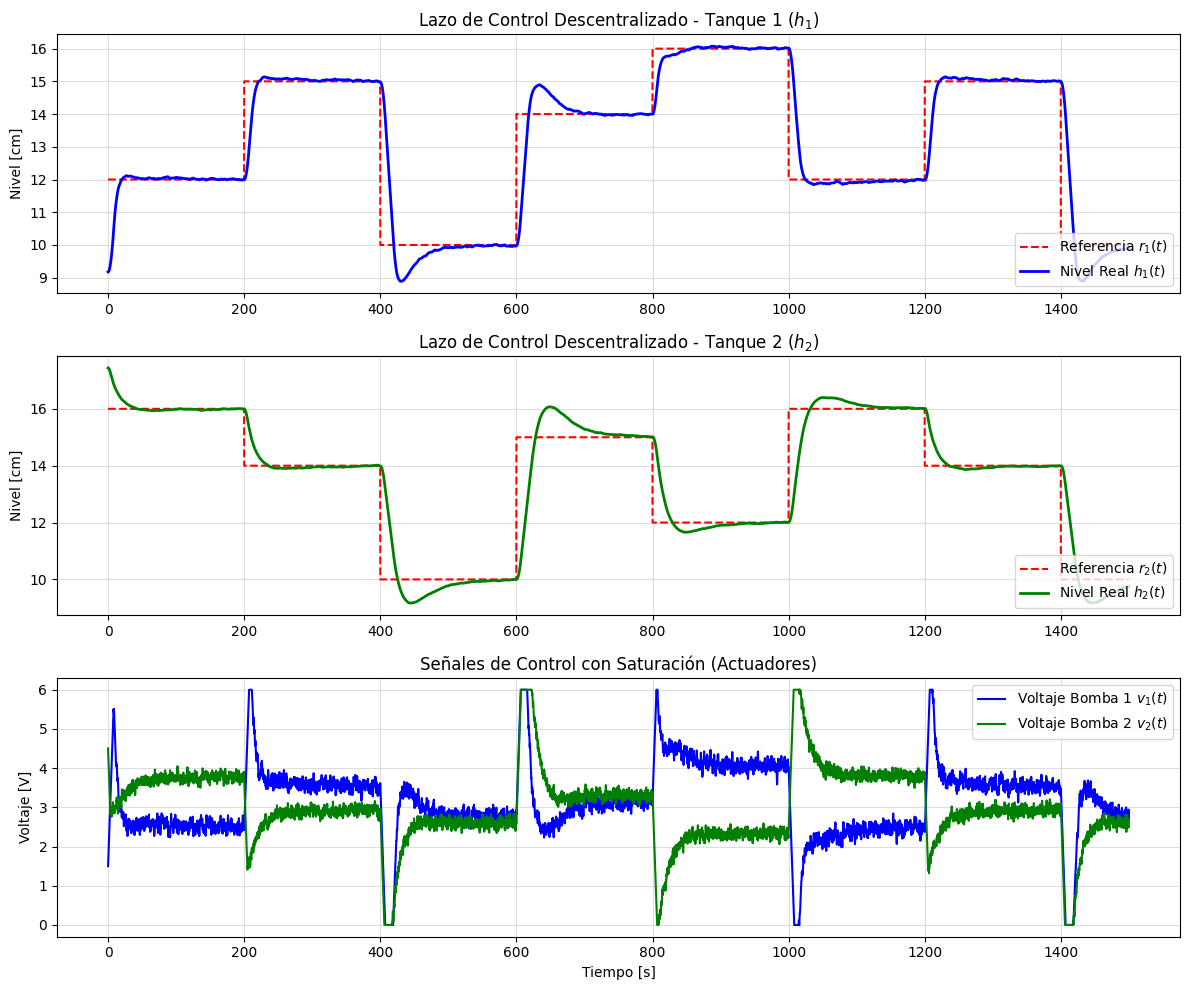

¡SIMULACIÓN FINALIZADA CON ÉXITO!


In [118]:
# --- CREACIÓN DE LAS GRÁFICAS DEL LAZO CERRADO ---
plt.figure(figsize=(12, 10))

# Subplot 1: Control del Tanque 1 (h1)
plt.subplot(3, 1, 1)
plt.plot(t_pid, r1_vec, 'r--', linewidth=1.5, label='Referencia $r_1(t)$')
plt.plot(t_pid, h1_cl, 'b', linewidth=2, label='Nivel Real $h_1(t)$')
plt.ylabel('Nivel [cm]')
plt.title('Lazo de Control Descentralizado - Tanque 1 ($h_1$)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.4)

# Subplot 2: Control del Tanque 2 (h2)
plt.subplot(3, 1, 2)
plt.plot(t_pid, r2_vec, 'r--', linewidth=1.5, label='Referencia $r_2(t)$')
plt.plot(t_pid, h2_cl, 'g', linewidth=2, label='Nivel Real $h_2(t)$')
plt.ylabel('Nivel [cm]')
plt.title('Lazo de Control Descentralizado - Tanque 2 ($h_2$)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.4)

# Subplot 3: Esfuerzo de Control (Voltajes v1 y v2)
plt.subplot(3, 1, 3)
plt.plot(t_pid, v1_cl, 'b', linewidth=1.5, label='Voltaje Bomba 1 $v_1(t)$')
plt.plot(t_pid, v2_cl, 'g', linewidth=1.5, label='Voltaje Bomba 2 $v_2(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.title('Señales de Control con Saturación (Actuadores)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("="*60)
print("¡SIMULACIÓN FINALIZADA CON ÉXITO!")
print("="*60)

In [119]:
# =====================================================================
# CÁLCULO DE MÉTRICAS DE CONTROL: LOCALES Y GLOBALES (PID ÓPTIMO)
# =====================================================================

def calculate_control_metrics(real, ref):
    error = real - ref
    sse = np.sum(error**2)
    rmse = np.sqrt(np.mean(error**2))

    # NRMSE normalizado por el rango de la referencia
    range_ref = np.max(ref) - np.min(ref)
    nrmse = rmse / range_ref if range_ref != 0 else rmse

    return sse, rmse, nrmse

# 1. Métricas Individuales utilizando los niveles reales (limpios) extraídos del PID
sse1, rmse1, nrmse1 = calculate_control_metrics(h1_cl, r1_vec)
sse2, rmse2, nrmse2 = calculate_control_metrics(h2_cl, r2_vec)

# 2. Métricas Globales (Sistema Completo MIMO de los dos tanques principales)
h_real_all = np.concatenate([h1_cl, h2_cl])
h_ref_all = np.concatenate([r1_vec, r2_vec])

sse_global, rmse_global, nrmse_global = calculate_control_metrics(h_real_all, h_ref_all)

# --- REPORTE EXTENDIDO EN CONSOLA ---
print("\n" + "="*75)
print(f"{'CONTROL METRIC':<25} | {'TANK 1 (h1)':<12} | {'TANK 2 (h2)':<12} | {'GLOBAL':<12}")
print("-" * 75)
print(f"{'SSE (Sum of Sq. Error)':<25} | {sse1:12.2f} | {sse2:12.2f} | {sse_global:12.2f}")
print(f"{'RMSE (Precision)':<25} | {rmse1:12.4f} | {rmse2:12.4f} | {rmse_global:12.4f}")
print(f"{'NRMSE (Normalized)':<25} | {nrmse1:12.4f} | {nrmse2:12.4f} | {nrmse_global:12.4f}")
print("="*75 + "\n")


CONTROL METRIC            | TANK 1 (h1)  | TANK 2 (h2)  | GLOBAL      
---------------------------------------------------------------------------
SSE (Sum of Sq. Error)    |      4983.28 |      5137.11 |     10120.39
RMSE (Precision)          |       0.8151 |       0.8276 |       0.8213
NRMSE (Normalized)        |       0.1358 |       0.1379 |       0.1369



In [120]:
# =====================================================================
# GUARDADO DE DATOS DE LA SIMULACIÓN (PID DESCENTRALIZADO OPTIMIZADO)
# =====================================================================
import pandas as pd

# 1. Creamos el diccionario con los datos nativos de la simulación PID
# Usamos .flatten() en el tiempo para asegurar dimensiones consistentes si fuera necesario
data_pid = {
    'Time_s': t_pid.flatten(),
    'h1_ref': r1_vec,
    'h2_ref': r2_vec,
    'h1_real_pid': h1_cl,
    'h2_real_pid': h2_cl,
    'h1_measured_pid': h1_measured_v,
    'h2_measured_pid': h2_measured_v,
    'v1_pump': v1_cl,
    'v2_pump': v2_cl
}

# 2. Convertimos a un DataFrame de Pandas
df_pid_results = pd.DataFrame(data_pid)

# 3. Guardamos en un archivo .csv
# index=False evita que se guarde una columna extra con los números de fila
nombre_archivo_csv = 'linear_taylor_pid_results_sinusoidal_10.csv'
#df_pid_results.to_csv(nombre_archivo_csv, index=False)

print("="*60)
print(f"Datos del PID guardados exitosamente como '{nombre_archivo_csv}'")
print("="*60)

Datos del PID guardados exitosamente como 'linear_taylor_pid_results_sinusoidal_10.csv'
